In [1]:
#Show plots inline, and load main getdist plot module and samples class
from __future__ import print_function
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))

import numpy as np
import pandas as pd
import math

import scipy as sp
import scipy.constants as scic
from scipy.interpolate import interp1d
import scipy.interpolate as intr
from scipy.stats import norm
from scipy.optimize import curve_fit
from IPython.display import HTML

import matplotlib
matplotlib.use('Agg')

import matplotlib as mpl
from matplotlib import rc
import matplotlib.pylab as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as ticker

from mpl_toolkits.axes_grid1 import make_axes_locatable
#from labellines import labelLine, labelLines

from classy import Class
from getdist import plots, MCSamples, loadMCSamples
#from cobaya import load_samples
#from cobaya.samplers.mcmc import plot_progress

#from uncertainties import ufloat, unumpy
#from util import *

%matplotlib inline

%config InlineBackend.figure_format = 'retina'
rc("font", weight="normal"); rc("font", size="20")
# Set the global font family to serif
mpl.rcParams['font.family'] = 'serif'
# Specify "Times New Roman" as the preferred serif font
#mpl.rcParams['font.serif'] = ['Times New Roman']

#rc("font", family='Times New Roman'); rc("font", style='italic')
rc("axes"); rc("axes",labelsize="18"); rc("xtick",labelsize="14"); rc("ytick",labelsize="14")#, labelweight="bold"
#plt.rcParams['text.usetex']=True
#plt.rcParams['text.latex.preamble'] = [r'\usepackage{sfmath} \boldmath']
font = {'family': 'Times New Roman', #'serif',#'monospace',
        'color': 'black',
        'weight': 'normal',
        'size': 16,
        'style':'italic', 
        
        }

In [2]:
from classy import Class

In [3]:
params_cmn = {'gauge': 'newtonian',
              'nonlinear_min_k_max': 25,
              'N_ncdm': 1,
              'N_ur': 2.046,
              'non linear': 'hmcode',
              'hmcode_version': 2020,
              'output' : 'tCl,pCl,lCl,mPk',
              'l_max_scalars': 9000, 
              'lensing': 'yes',
            }

In [4]:
params_lcdm =  {'Omega_fld': 0,
                'Omega_scf': 0}
params_cmn.update(params_lcdm)

In [5]:
%%time
Model_LCDM = Class()
Model_LCDM.set(params_cmn)
Model_LCDM.compute()
BackQunt_LCDM = Model_LCDM.get_background()

CPU times: user 3min 8s, sys: 11.3 s, total: 3min 19s
Wall time: 11.9 s


In [6]:
# ── New model: b = -a, kappa parameterization ──
# Sampled params
f_x     = -0.15               # tilde{f}_x: fractional exotic contribution at z_c
z_c_exo = 18         # window center
kappa   = 0.2                 # e-fold width (fixed)

# Derived params
sigma_z_exo = kappa * (1.0 + z_c_exo)   # redshift width from kappa

# E^2_LCDM at z_c (Planck fiducial)
Omega_m  = 0.31
Omega_r  = 9.24e-5
Omega_L  = 1.0 - Omega_m - Omega_r
E2_LCDM  = Omega_m*(1+z_c_exo)**3 + Omega_r*(1+z_c_exo)**4 + Omega_L

# a_exo from f_x
a_exo = f_x * (1.0 + z_c_exo) * E2_LCDM
b_exo = -a_exo                            # b = -a model

# Derived for reporting
Omega_x0 = a_exo * np.exp(-z_c_exo**2 / (2.0 * sigma_z_exo**2))

print(f"z_c     = {z_c_exo}")
print(f"kappa   = {kappa}")
print(f"sigma_z = {sigma_z_exo:.2f}")
print(f"f_x     = {f_x}")
print(f"a_exo   = {a_exo:.1f}")
print(f"b_exo   = {b_exo:.1f}")
print(f"Omega_x0= {Omega_x0:.4e}")
print(f"E2_LCDM = {E2_LCDM:.1f}")

z_c     = 18
kappa   = 0.2
sigma_z = 3.80
f_x     = -0.15
a_exo   = -6096.2
b_exo   = 6096.2
Omega_x0= -8.1805e-02
E2_LCDM = 2139.0


In [7]:
# (1+z_cmb)/z_cmb

In [8]:
# ── Physicality bound: E^2 >= (1-f_floor) * E^2_LCDM ──
f_floor = 0.2   # max allowed fractional suppression

# With b=-a: amp(z) = a/(1+z), so Delta E^2 = a*G(z)/(1+z)
# Worst-case z is slightly below z_c (Gaussian * 1/(1+z) peaks there)
# Conservative single-point bound at z_c (where G=1):
#   a / (1+z_c) >= -f_floor * E^2_LCDM(z_c)
a_limit   = -f_floor * (1.0 + z_c_exo) * E2_LCDM
f_x_limit = -f_floor   # by construction

print(f"a_exo  must be >= {a_limit:.1f}")
print(f"f_x    must be >= {f_x_limit}")
print(f"(current a_exo = {a_exo:.1f}, f_x = {f_x})")

a_exo  must be >= -8128.3
f_x    must be >= -0.2
(current a_exo = -6096.2, f_x = -0.15)


In [9]:
params_exo = {'Omega_fld': 0,
              'Omega_scf': 0,
              'a_exo': a_exo,
              'z_c_exo': z_c_exo,
              'sigma_z_exo': sigma_z_exo,
             }
params_cmn.update(params_exo)

In [10]:
%%time
Model = Class()
Model.set(params_cmn)
Model.compute()
BackQunt = Model.get_background()

CPU times: user 3min 8s, sys: 11.1 s, total: 3min 19s
Wall time: 11.9 s


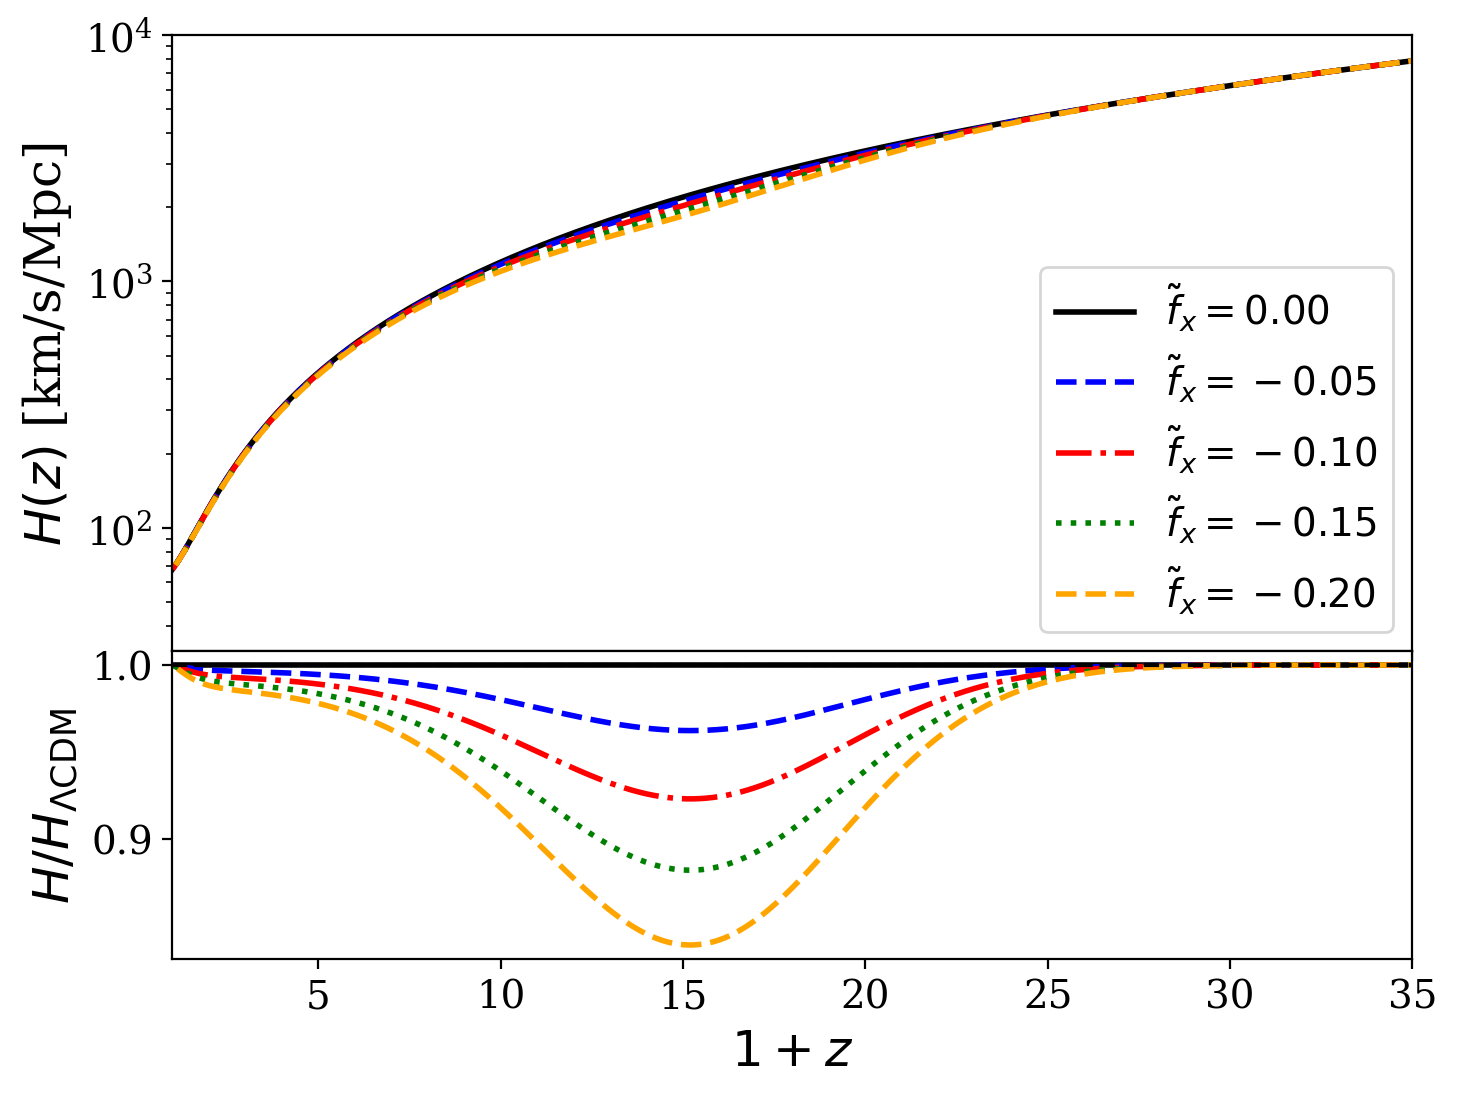

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0.0)

f_x_arr = np.array([0.0, -0.05, -0.1, -0.15, -0.20])
lstyls  = ['-', '--', '-.', ':', '--']
colors  = ['k', 'b', 'r', 'g', 'orange']
labels  = [rf'$\tilde{{f}}_x = {f:.2f}$' for f in f_x_arr]

for i, fx in enumerate(f_x_arr):
    a_i = fx * (1.0 + z_c_exo) * E2_LCDM
    b_i = -a_i
    sigma_i = kappa * (1.0 + z_c_exo)
    params_exo.update({'a_exo': a_i, 'sigma_z_exo': sigma_i, 'z_c_exo': z_c_exo})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BQ = Model.get_background()
    ax1.plot(1 + BQ['z'], 1e-3*scic.c*BQ['H [1/Mpc]'],
             ls=lstyls[i], lw=2., c=colors[i], label=labels[i])
    ax2.plot(1 + BQ['z'],
             1e-3*scic.c*BQ['H [1/Mpc]'] / (1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']),
             ls=lstyls[i], lw=2., c=colors[i])
    Model.struct_cleanup()

ax2.axhline(1.0, ls='--', lw=1.5, c='k')
ax1.set_yscale('log')
ax1.legend(fontsize=14)
ax2.set_xlim(1, 60)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$ [km/s/Mpc]', fontsize=18)
ax2.set_ylabel(r'$H/H_{\Lambda\mathrm{CDM}}$', fontsize=18)
ax1.set_xlim(1, 35) ; ax1.set_ylim(10**1.5, 10**4)
plt.show()

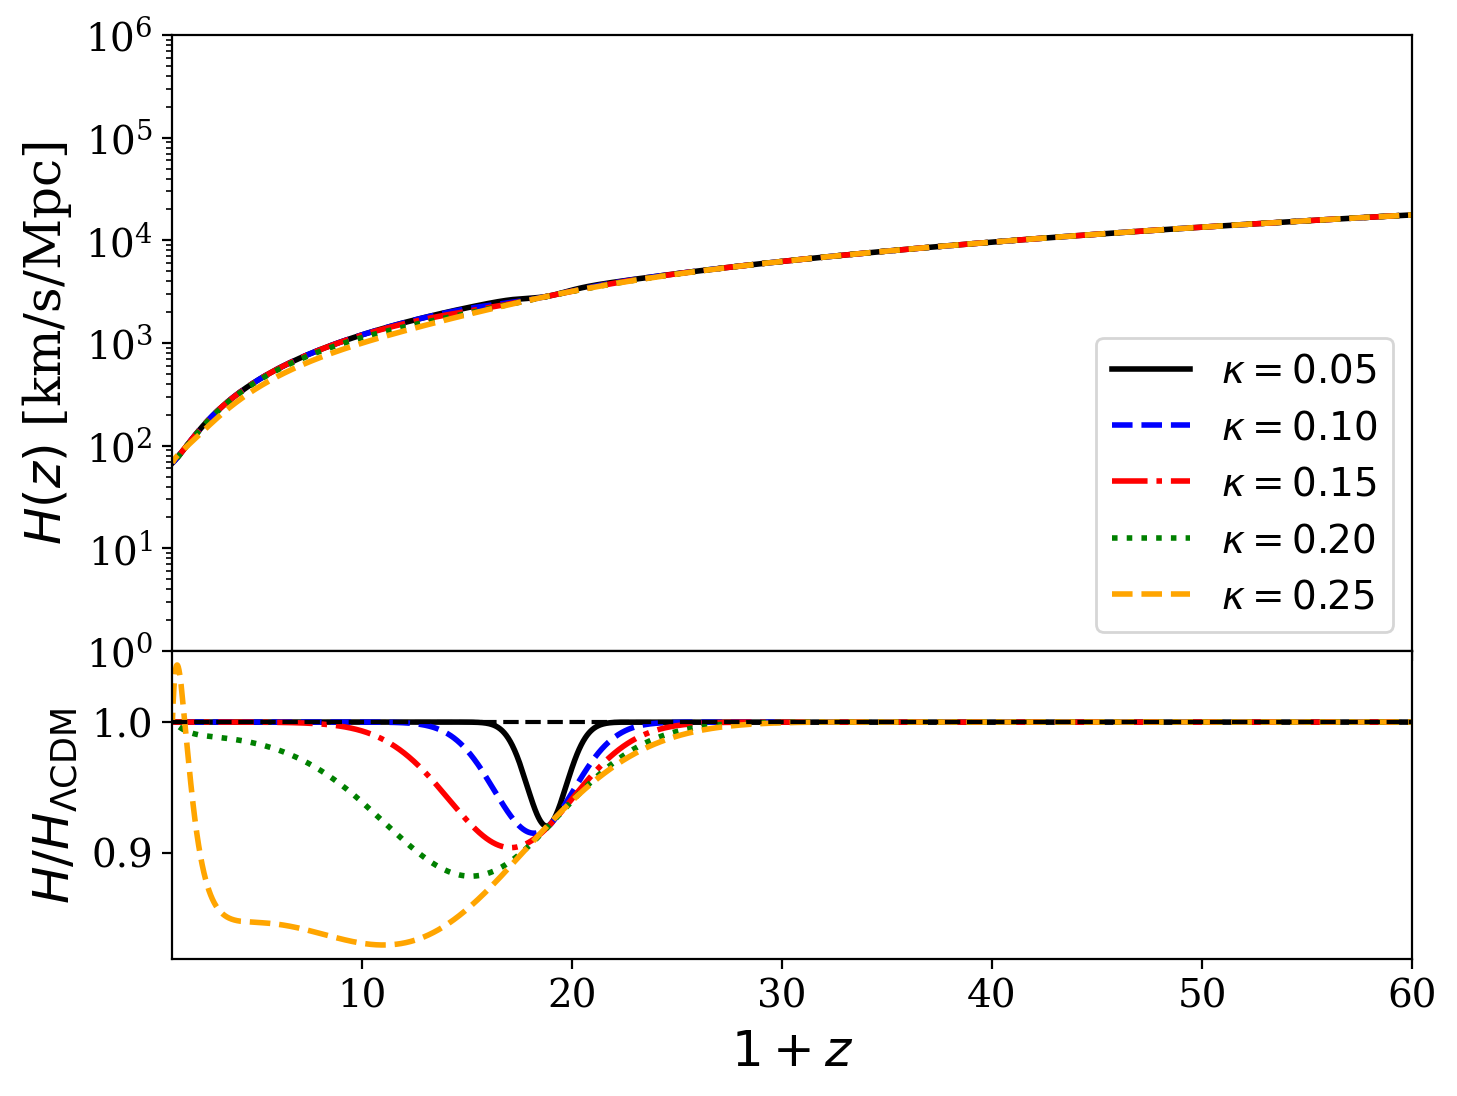

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0.0)

kappa_arr = np.array([0.05, 0.10, 0.15, 0.20, 0.25])
lstyls  = ['-', '--', '-.', ':', '--']
colors  = ['k', 'b', 'r', 'g', 'orange']
labels    = [rf'$\kappa = {k:.2f}$' for k in kappa_arr]

fx = -0.15

for i, kappa in enumerate(kappa_arr):
    a_i = fx * (1.0 + z_c_exo) * E2_LCDM
    b_i = -a_i
    sigma_i = kappa * (1.0 + z_c_exo)
    params_exo.update({'a_exo': a_i, 'sigma_z_exo': sigma_i, 'z_c_exo': z_c_exo})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BQ = Model.get_background()
    ax1.plot(1 + BQ['z'], 1e-3*scic.c*BQ['H [1/Mpc]'],
             ls=lstyls[i], lw=2., c=colors[i], label=labels[i])
    ax2.plot(1 + BQ['z'],
             1e-3*scic.c*BQ['H [1/Mpc]'] / (1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']),
             ls=lstyls[i], lw=2., c=colors[i])
    Model.struct_cleanup()

ax2.axhline(1.0, ls='--', lw=1.5, c='k')
ax1.set_yscale('log')
ax1.set_ylim(1, 1e6)
ax1.legend(fontsize=14)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$ [km/s/Mpc]', fontsize=18)
ax2.set_ylabel(r'$H/H_{\Lambda\mathrm{CDM}}$', fontsize=18)
ax1.set_xlim(1, 60)
plt.show()

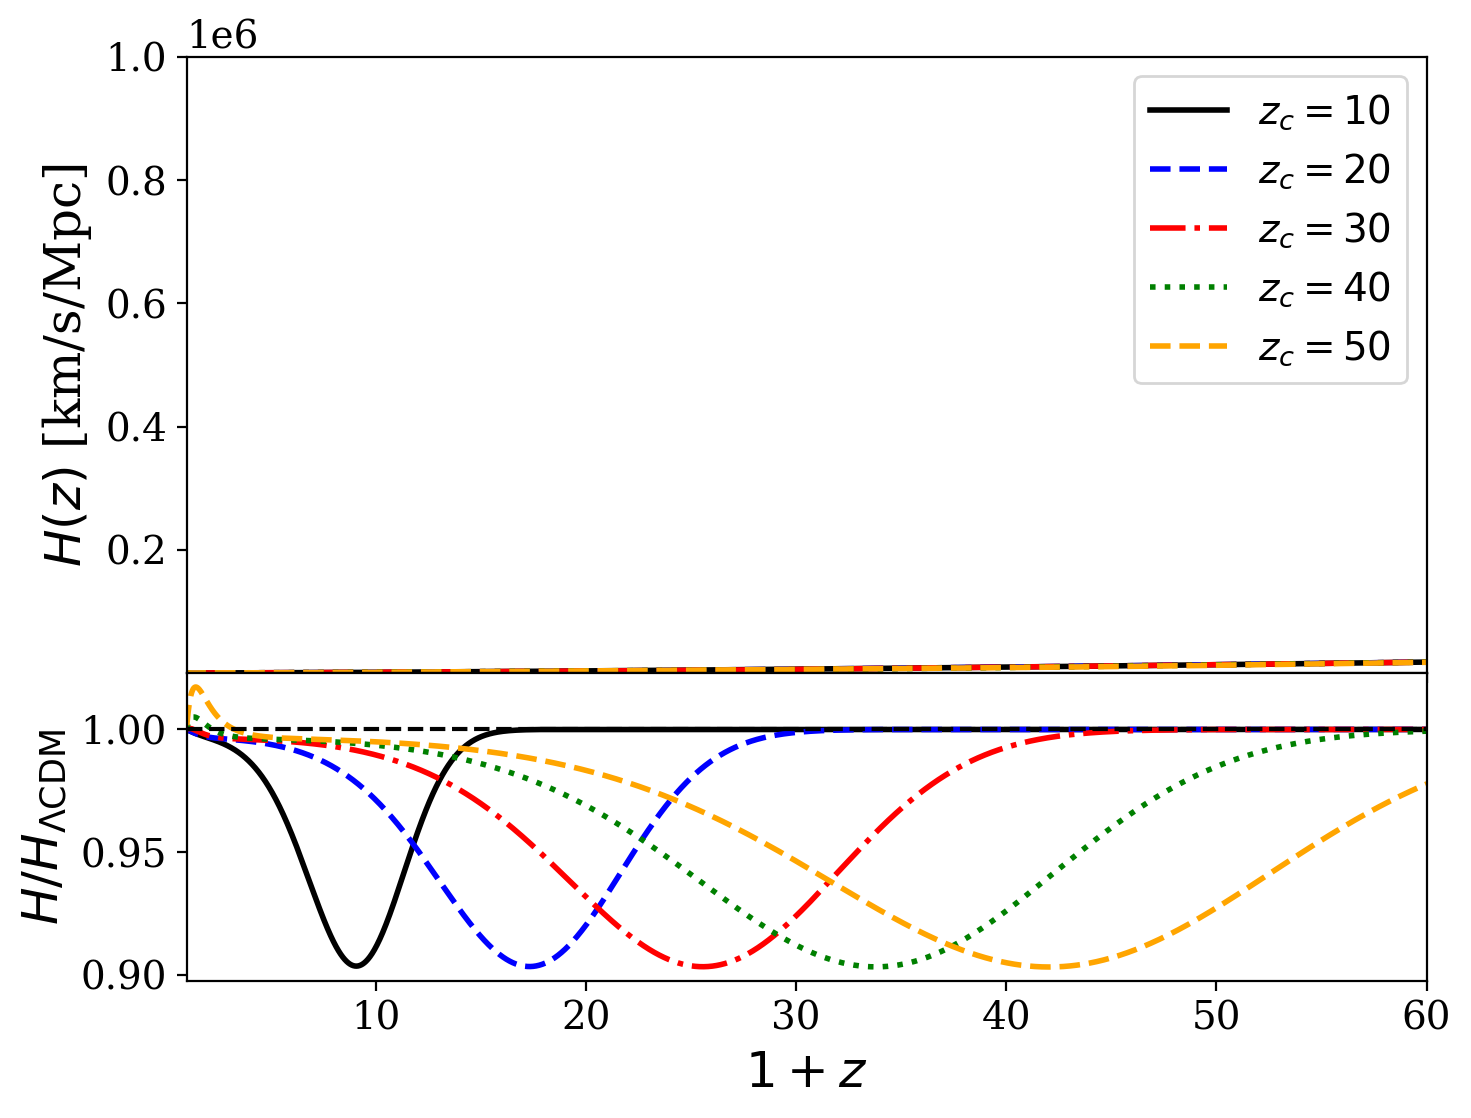

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=(2, 1))
plt.subplots_adjust(hspace=0.0)

zc_arr  = np.array([10., 20., 30., 40., 50.])
lstyls  = ['-', '--', '-.', ':', '--']
colors  = ['k', 'b', 'r', 'g', 'orange']
labels  = [rf'$z_c = {z:.0f}$' for z in zc_arr]

fx = -0.13
kappa = 0.19

for i, zc in enumerate(zc_arr):
    E2_LCDM_i = Omega_m * (1 + zc)**3 + Omega_r * (1 + zc)**4 + Omega_L
    a_i = fx * (1 + zc) * E2_LCDM_i
    b_i = -a_i
    sigma_i = kappa * (1.0 + zc)
    
    params_exo.update({'a_exo': a_i,
                       
                       'z_c_exo': zc, 'sigma_z_exo': sigma_i})
    params_cmn.update(params_exo)
    Model.set(params_cmn)
    Model.compute()
    BQ = Model.get_background()
    ax1.plot(1 + BQ['z'], 1e-3*scic.c*BQ['H [1/Mpc]'],
             ls=lstyls[i], lw=2., c=colors[i], label=labels[i])
    ax2.plot(1 + BQ['z'],
             1e-3*scic.c*BQ['H [1/Mpc]'] / (1e-3*scic.c*BackQunt_LCDM['H [1/Mpc]']),
             ls=lstyls[i], lw=2., c=colors[i])
    Model.struct_cleanup()

ax2.axhline(1.0, ls='--', lw=1.5, c='k')
ax1.legend(fontsize=14)
ax1.set_ylim(1, 1e6)
ax2.set_xlabel(r'$1 + z$', fontsize=18)
ax1.set_ylabel(r'$H(z)$ [km/s/Mpc]', fontsize=18)
ax2.set_ylabel(r'$H/H_{\Lambda\mathrm{CDM}}$', fontsize=18)
ax1.set_xlim(1, 60)
plt.show()

In [15]:
# ── Round-trip check: does the f_x we put in come back out of CLASS? ──
# This is the single most important validation cell. If this prints ratio ≈ 1.000,
# the entire parameterization (f_x → a → CLASS → rho_exo → f_x) is wired correctly.

from scipy.interpolate import interp1d

# Use whatever (f_x, z_c, kappa) Cell 5 currently has
print(f"INPUT:  f_x = {f_x},  z_c = {z_c_exo},  kappa = {kappa}")
print(f"        a_exo = {a_exo:.2f},  b_exo = {b_exo:.2f},  sigma_z = {sigma_z_exo:.2f}")
print()

# 1. Read rho_exo and rho_crit from CLASS output at z_c
BQ = Model.get_background()
rho_exo_at_zc  = interp1d(BQ['z'], BQ['(.)rho_exo'])(z_c_exo)
rho_crit_at_zc = interp1d(BQ['z'], BQ['(.)rho_crit'])(z_c_exo)

# 2. f_x = rho_exo / rho_crit  (both in CLASS internal units, so the (8piG/3) cancels)
f_x_readback = rho_exo_at_zc / rho_crit_at_zc

# 3. Also check via the cancelled form: a / [(1+z_c) * E^2_LCDM]
#    using CLASS's own Omega_m (not fiducial) to see the fiducial offset
H0_class   = BQ['H [1/Mpc]'][-1]              # H(z→0) = H0 in 1/Mpc
rho_crit_0 = rho_crit_at_zc_0 = interp1d(BQ['z'], BQ['(.)rho_crit'])(0.0)
Omega_m_class = (interp1d(BQ['z'], BQ['(.)rho_cdm'])(0.0) +
                 interp1d(BQ['z'], BQ['(.)rho_b'])(0.0)) / rho_crit_0
E2_true = interp1d(BQ['z'], (BQ['H [1/Mpc]']/H0_class)**2)(z_c_exo)
f_x_analytic = a_exo / ((1.0 + z_c_exo) * E2_true)

print(f"FROM CLASS (.)rho_exo/(.)rho_crit at z_c:")
print(f"  rho_exo(z_c)  = {rho_exo_at_zc:.6e}")
print(f"  rho_crit(z_c) = {rho_crit_at_zc:.6e}")
print(f"  f_x readback  = {f_x_readback:.6f}")
print()
print(f"FROM a/(1+z_c)/E^2_true (using CLASS's own H(z)):")
print(f"  Omega_m(CLASS) = {Omega_m_class:.5f}  (fiducial was {Omega_m})")
print(f"  E^2_true(z_c)  = {E2_true:.2f}  (fiducial was {E2_LCDM:.2f})")
print(f"  f_x analytic   = {f_x_analytic:.6f}")
print()
print(f"COMPARISON:")
print(f"  f_x input      = {f_x}")
print(f"  f_x readback   = {f_x_readback:.6f}   (ratio to input: {f_x_readback/f_x:.6f})")
print(f"  f_x analytic   = {f_x_analytic:.6f}   (ratio to input: {f_x_analytic/f_x:.6f})")
print()

if abs(f_x_readback/f_x - 1) < 0.03:
    print("PASS: readback matches input to <3%. Parameterization is wired correctly.")
    print(f"  The {abs(f_x_readback/f_x - 1)*100:.1f}% offset is the fiducial-vs-true E^2 difference.")
else:
    print("*** FAIL ***: readback differs from input by >3%. Something is broken.")
    print("  Check: is b_exo == -a_exo? Is sigma_z == kappa*(1+z_c)?")
    print("  Check: did Cell 5 run BEFORE Cell 10 (the CLASS compute)?")
    
    
from scipy.interpolate import interp1d

BQ = Model.get_background()

# Get H0 and build E^2_LCDM from CLASS's own cosmology (no exotic)
H0_class = BQ['H [1/Mpc]'][-1]   # H at z≈0

# rho_exo at z_c
rho_exo_zc = interp1d(BQ['z'], BQ['(.)rho_exo'])(z_c_exo)

# E^2_LCDM = (H^2 - rho_exo) / H0^2   (subtract the exotic piece to get pure LCDM)
H2_at_zc   = interp1d(BQ['z'], BQ['H [1/Mpc]']**2)(z_c_exo)
E2_LCDM_true = (H2_at_zc - rho_exo_zc) / H0_class**2

f_x_readback = rho_exo_zc / (H0_class**2 * E2_LCDM_true)

print(f"INPUT:   f_x = {f_x}")
print(f"READBACK: f_x = {f_x_readback:.6f}")
print(f"RATIO:   {f_x_readback/f_x:.6f}")

INPUT:  f_x = -0.15,  z_c = 18,  kappa = 0.19
        a_exo = -6096.21,  b_exo = 6096.21,  sigma_z = 3.80

FROM CLASS (.)rho_exo/(.)rho_crit at z_c:
  rho_exo(z_c)  = -3.193023e-06
  rho_crit(z_c) = 1.062173e-04
  f_x readback  = -0.030061

FROM a/(1+z_c)/E^2_true (using CLASS's own H(z)):
  Omega_m(CLASS) = 0.30988  (fiducial was 0.31)
  E^2_true(z_c)  = 2076.10  (fiducial was 2139.02)
  f_x analytic   = -0.154546

COMPARISON:
  f_x input      = -0.15
  f_x readback   = -0.030061   (ratio to input: 0.200408)
  f_x analytic   = -0.154546   (ratio to input: 1.030305)

*** FAIL ***: readback differs from input by >3%. Something is broken.
  Check: is b_exo == -a_exo? Is sigma_z == kappa*(1+z_c)?
  Check: did Cell 5 run BEFORE Cell 10 (the CLASS compute)?
INPUT:   f_x = -0.15
READBACK: f_x = -0.029184
RATIO:   0.194560


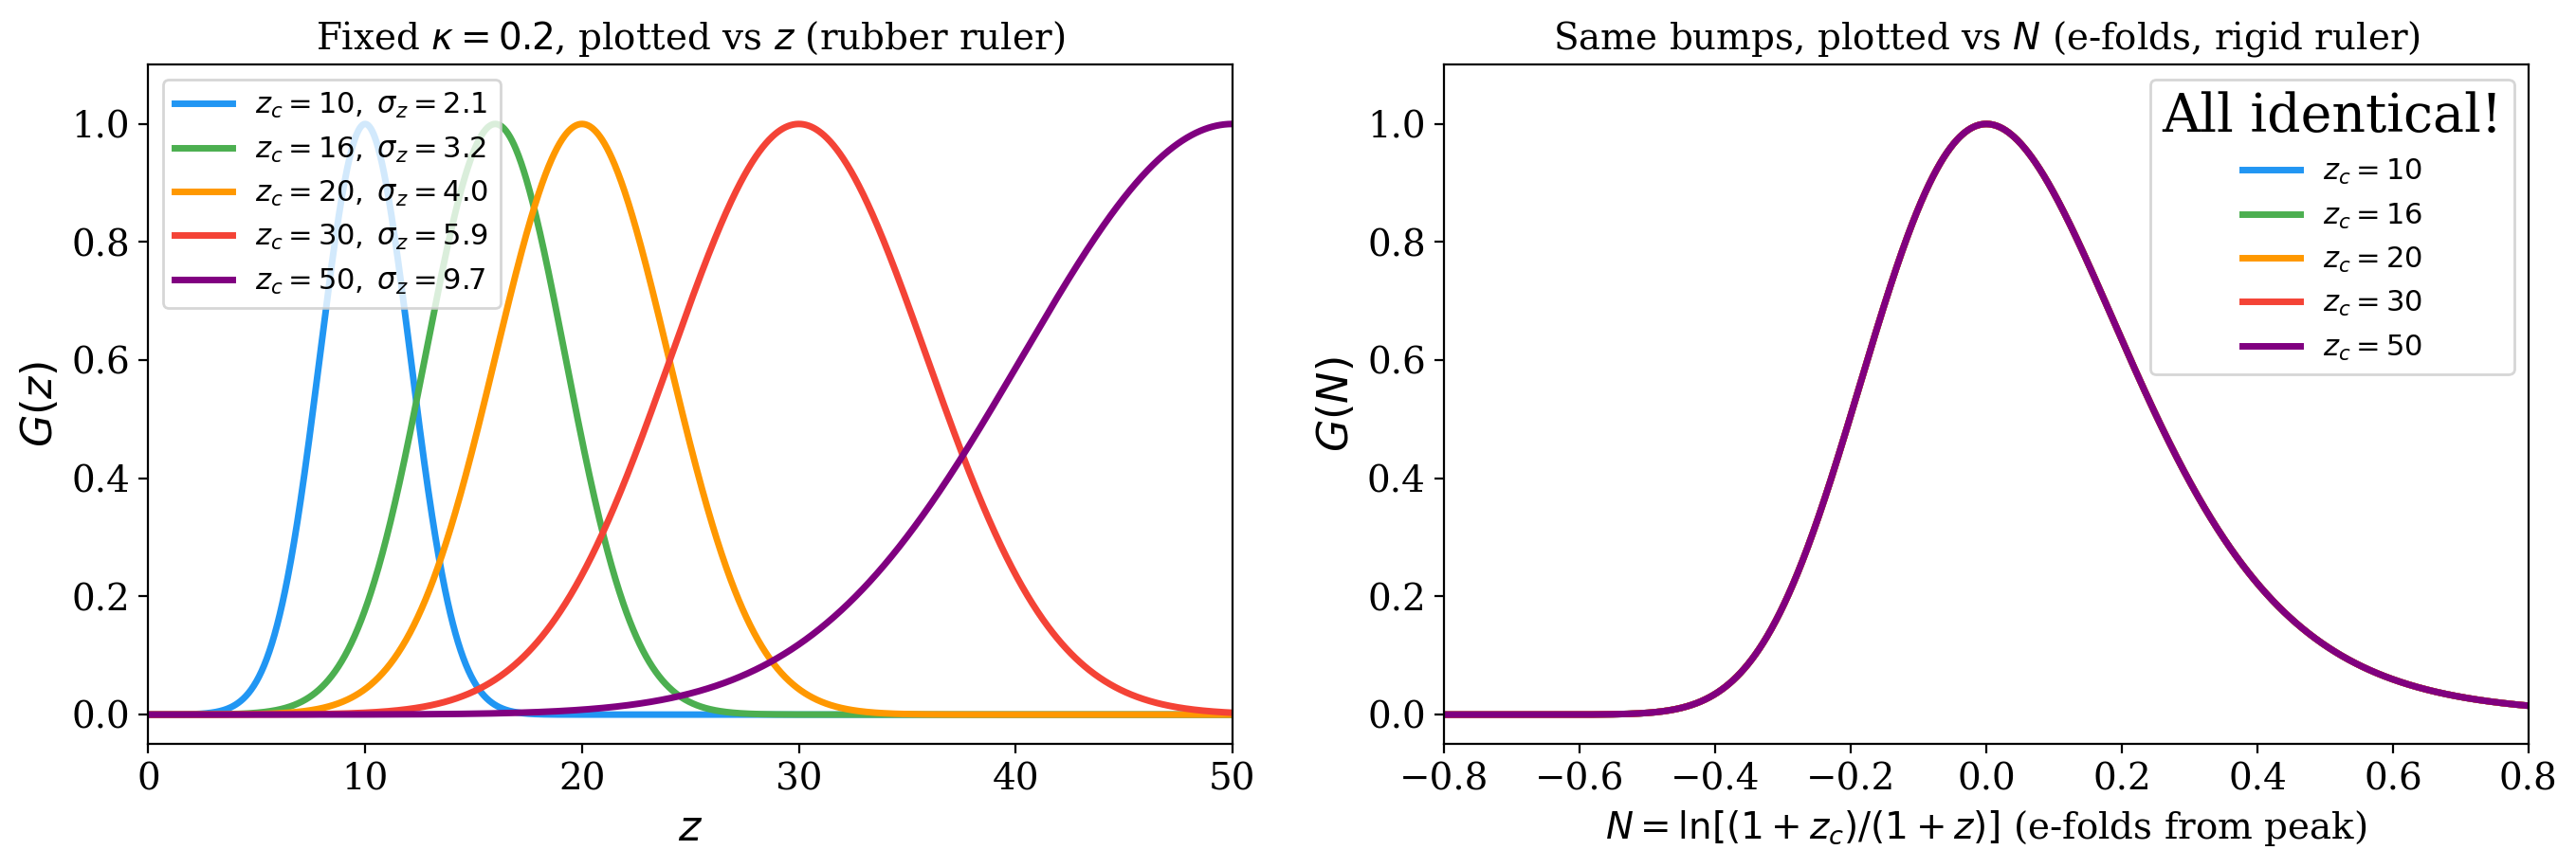

In [16]:
# ── kappa demo: same bump at different z_c ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_arr = np.linspace(0, 150 , 5000)
zc_list = [10, 16, 20, 30, 50]
colors_zc = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', 'purple']

# Left panel: G(z) vs z — looks different (rubber ruler)
ax = axes[0]
ax.set_title(r'Fixed $\kappa=0.2$, plotted vs $z$ (rubber ruler)', fontsize=14)
for zc, col in zip(zc_list, colors_zc):
    sig = kappa * (1.0 + zc)
    G = np.exp(-(z_arr - zc)**2 / (2.0 * sig**2))
    ax.plot(z_arr, G, lw=2.5, c=col, label=rf'$z_c={zc},\;\sigma_z={sig:.1f}$')
ax.set_xlabel(r'$z$', fontsize=16)
ax.set_ylabel(r'$G(z)$', fontsize=16)
ax.legend(fontsize=11)
ax.set_xlim(0, 50)
ax.set_ylim(-0.05, 1.1)

# Right panel: G(N) vs N — all identical (rigid ruler)
ax = axes[1]
ax.set_title(r'Same bumps, plotted vs $N$ (e-folds, rigid ruler)', fontsize=14)
N_arr = np.linspace(-0.8, 0.8, 2000)
for zc, col in zip(zc_list, colors_zc):
    # G(N) = exp(-(e^{-N} - 1)^2 / (2 kappa^2))  — no z_c
    GN = np.exp(-(np.exp(-N_arr) - 1)**2 / (2.0 * kappa**2))
    ax.plot(N_arr, GN, lw=2.5, c=col, label=rf'$z_c={zc}$')
ax.set_xlabel(r'$N = \ln[(1+z_c)/(1+z)]$ (e-folds from peak)', fontsize=14)
ax.set_ylabel(r'$G(N)$', fontsize=16)
ax.legend(fontsize=11, title='All identical!')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

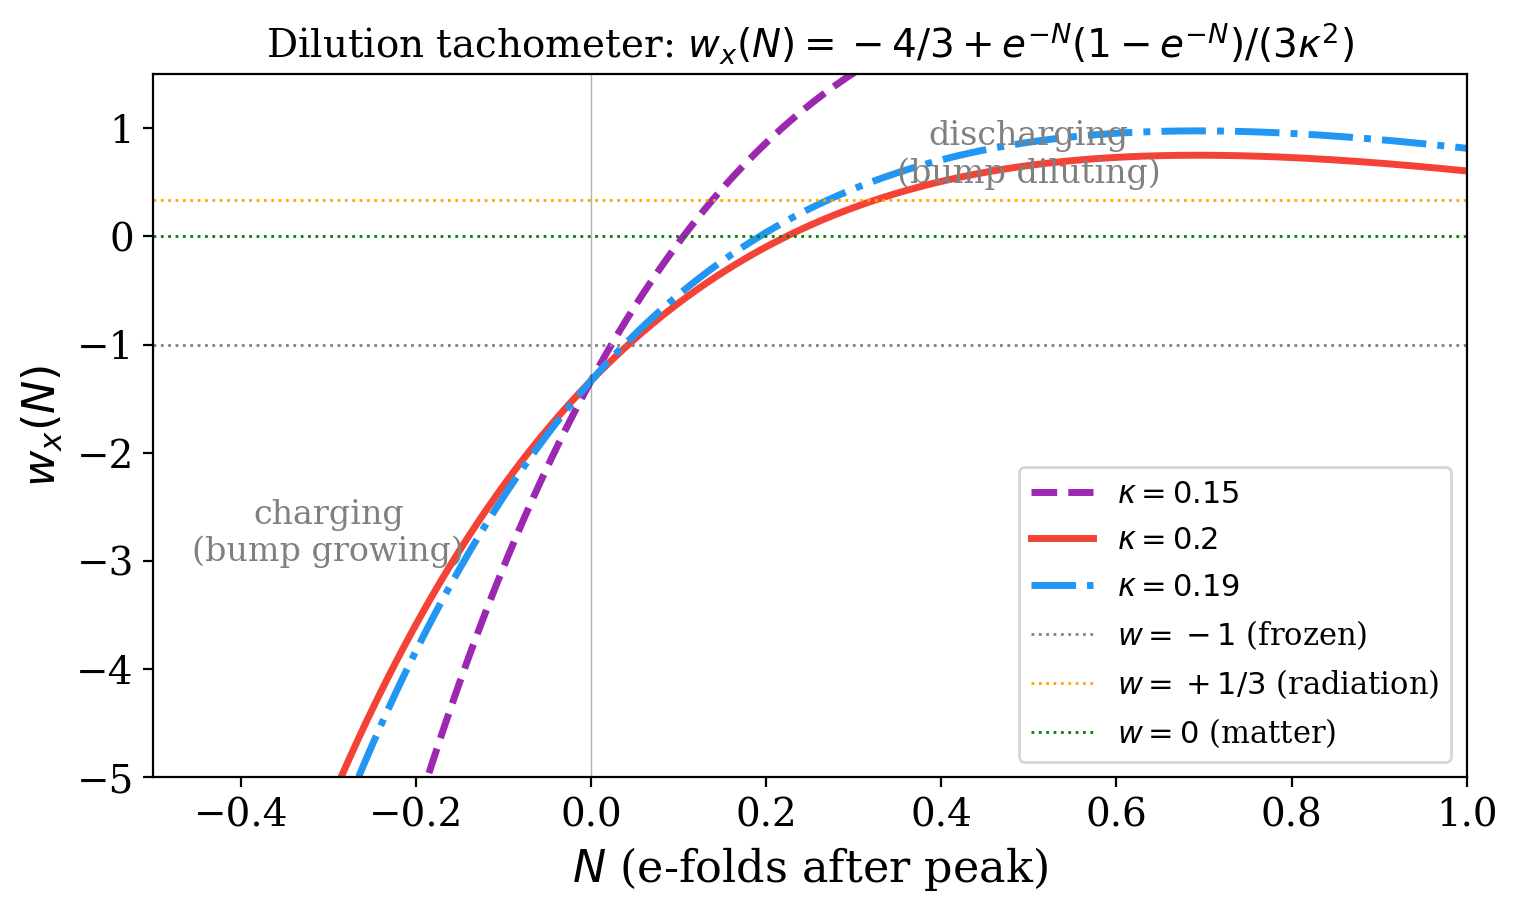

In [17]:
# ── w_x(N) tachometer ──
fig, ax = plt.subplots(figsize=(8, 5))
N_arr = np.linspace(-0.5, 1.0, 1000)

for k, col, ls in [(0.15, '#9C27B0', '--'), (0.2, '#F44336', '-'), (0.19, '#2196F3', '-.')]:
    wx = -4.0/3.0 + np.exp(-N_arr)*(1.0 - np.exp(-N_arr)) / (3.0*k**2)
    ax.plot(N_arr, wx, lw=2.5, c=col, ls=ls, label=rf'$\kappa={k}$')

ax.axhline(-1.0, ls=':', c='grey', lw=1, label=r'$w=-1$ (frozen)')
ax.axhline(1./3, ls=':', c='orange', lw=1, label=r'$w=+1/3$ (radiation)')
ax.axhline(0.0, ls=':', c='green', lw=1, label=r'$w=0$ (matter)')
ax.axvline(0.0, ls='-', c='k', lw=0.5, alpha=0.3)

ax.set_xlabel(r'$N$ (e-folds after peak)', fontsize=16)
ax.set_ylabel(r'$w_x(N)$', fontsize=16)
ax.set_title(r'Dilution tachometer: $w_x(N) = -4/3 + e^{-N}(1-e^{-N})/(3\kappa^2)$', fontsize=14)
ax.set_xlim(-0.5, 1.0)
ax.set_ylim(-5, 1.5)
ax.legend(fontsize=11, loc='lower right')
ax.annotate('charging\n(bump growing)', xy=(-0.3, -3), fontsize=12, color='grey', ha='center')
ax.annotate('discharging\n(bump diluting)', xy=(0.5, 0.5), fontsize=12, color='grey', ha='center')
plt.tight_layout()
plt.show()

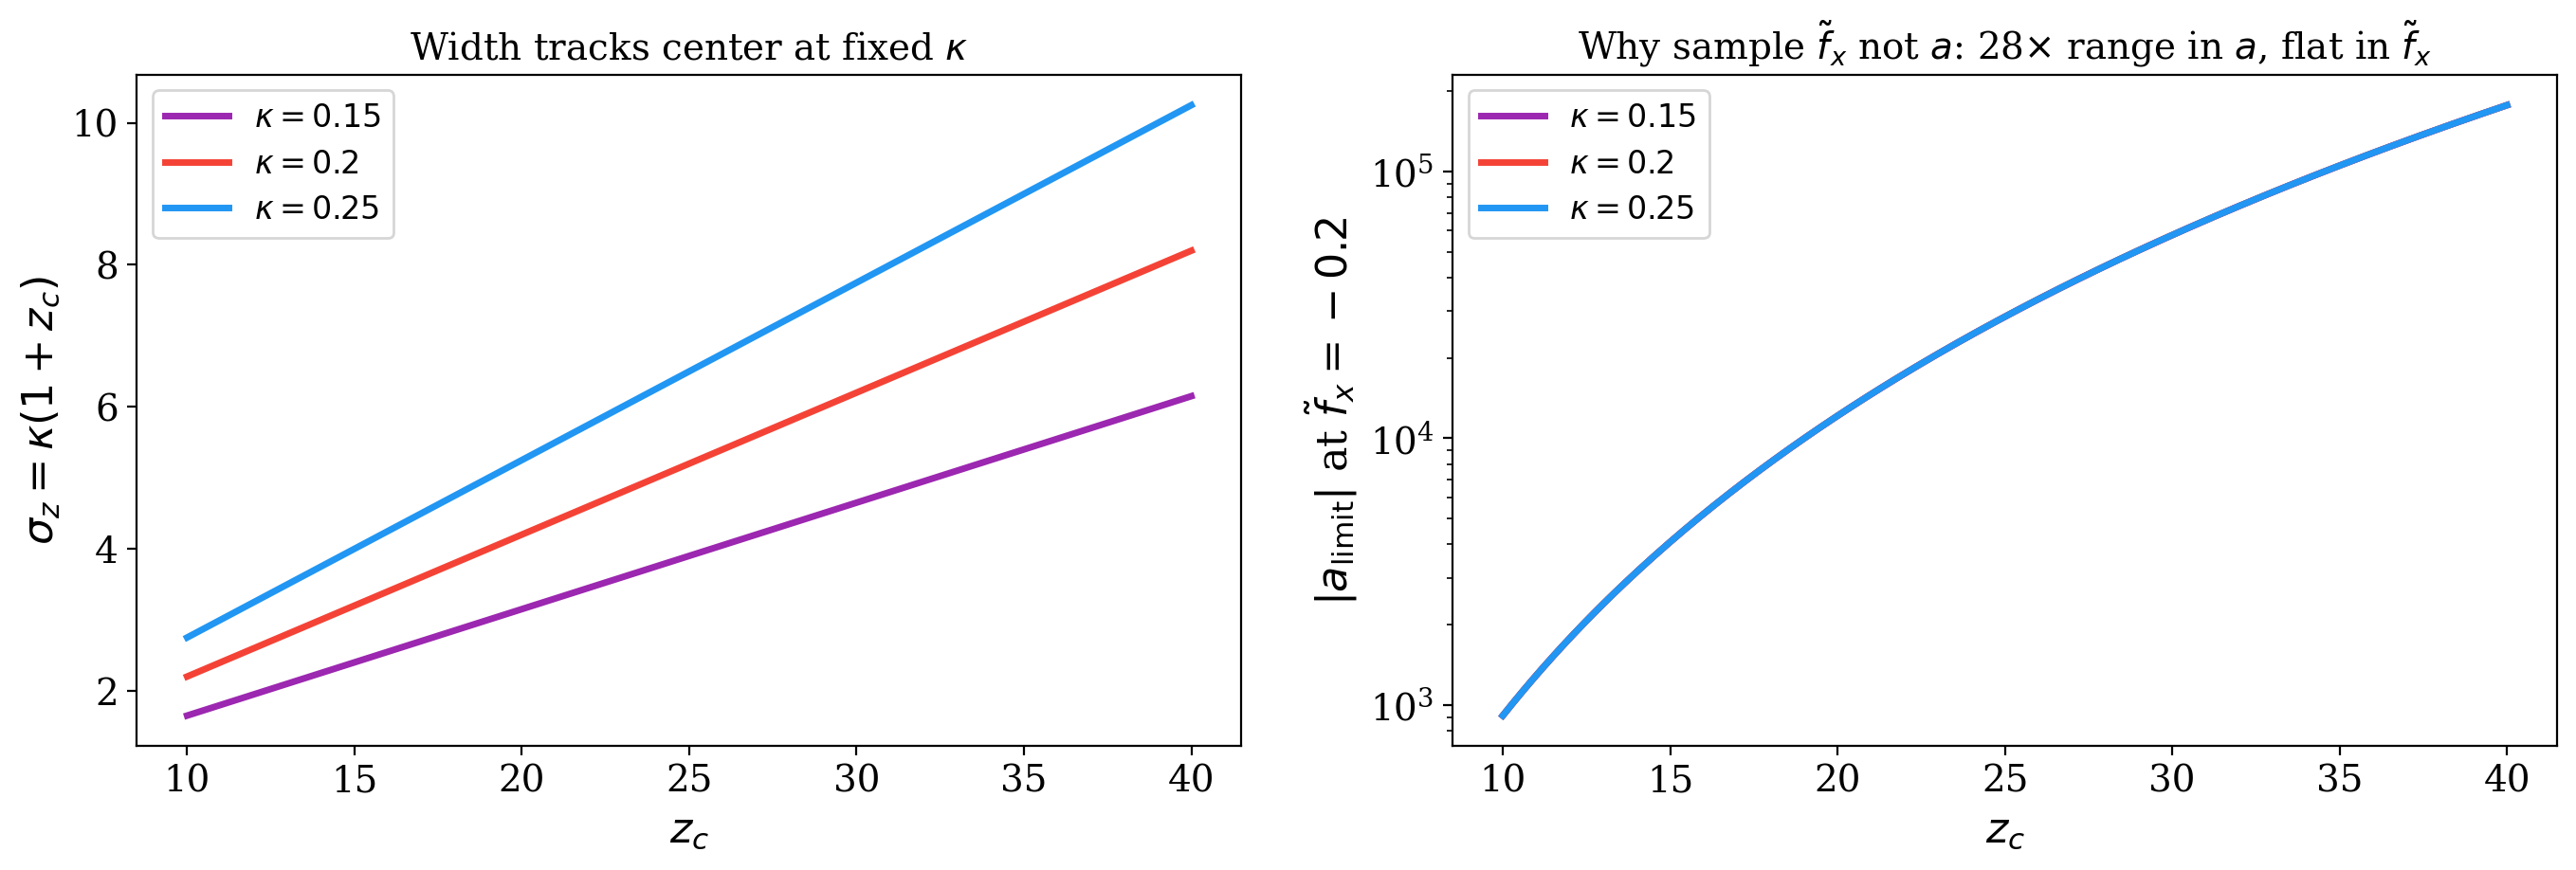

In [18]:
# ── sigma_z vs z_c at fixed kappa, and physicality bound on f_x ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

zc_range = np.linspace(10, 40, 200)

# Left: sigma_z vs z_c
for k, col in [(0.15, '#9C27B0'), (0.2, '#F44336'), (0.25, '#2196F3')]:
    ax1.plot(zc_range, k*(1+zc_range), lw=2.5, c=col, label=rf'$\kappa={k}$')
ax1.set_xlabel(r'$z_c$', fontsize=16)
ax1.set_ylabel(r'$\sigma_z = \kappa(1+z_c)$', fontsize=16)
ax1.legend(fontsize=12)
ax1.set_title(r'Width tracks center at fixed $\kappa$', fontsize=14)

# Right: a_limit vs z_c (physicality f_x >= -0.2)
for k, col in [(0.15, '#9C27B0'), (0.2, '#F44336'), (0.25, '#2196F3')]:
    E2 = Omega_m*(1+zc_range)**3 + Omega_r*(1+zc_range)**4 + Omega_L
    a_lim = -0.2 * (1+zc_range) * E2
    ax2.semilogy(zc_range, np.abs(a_lim), lw=2.5, c=col, label=rf'$\kappa={k}$')
ax2.set_xlabel(r'$z_c$', fontsize=16)
ax2.set_ylabel(r'$|a_{\rm limit}|$ at $\tilde{f}_x = -0.2$', fontsize=16)
ax2.legend(fontsize=12)
ax2.set_title(r'Why sample $\tilde{f}_x$ not $a$: 28$\times$ range in $a$, flat in $\tilde{f}_x$', fontsize=14)

plt.tight_layout()
plt.show()

In [19]:
import classy
print(classy.__file__)

/home/ahmed.omar/workspace/pyenvs/analysis_env_2.0/lib/python3.9/site-packages/classy/__init__.py


In [20]:
import sys, os
print("executable:", sys.executable)
print("PYTHONUSERBASE:", os.environ.get("PYTHONUSERBASE"))
import site
print("user site:", site.getusersitepackages())

import classy
print("classy path:", classy.__file__)
print("classy version:", classy.__version__ if hasattr(classy, '__version__') else "n/a")

executable: /bin/python3.9
PYTHONUSERBASE: /home/ahmed.omar/workspace/pyenvs/analysis_env_2.0
user site: /home/ahmed.omar/workspace/pyenvs/analysis_env_2.0/lib/python3.9/site-packages
classy path: /home/ahmed.omar/workspace/pyenvs/analysis_env_2.0/lib/python3.9/site-packages/classy/__init__.py
classy version: v3.3.4


In [21]:
BQ = Model.get_background()
print("max |p_exo|:", np.abs(BQ['(.)p_exo']).max())
print("max |rho_exo|:", np.abs(BQ['(.)rho_exo']).max())

max |p_exo|: 0.0005231691816074035
max |rho_exo|: 0.0002829184551298093


In [22]:
BQ = Model.get_background()
z = BQ['z']
rho = BQ['(.)rho_exo']
p   = BQ['(.)p_exo']

zc  = params_cmn['z_c_exo']
sig = params_cmn['sigma_z_exo']

# Mask to the CORE of the window (within 2.5 sigma) where rho is far from the FP floor
mask = np.abs(z - zc) < 2.5 * sig
mask &= np.abs(rho) > 1e-4 * np.abs(rho).max()   # extra guard

zz = z[mask]
wx_class = p[mask] / rho[mask]
wx_analytic = -4/3 + (1+zz)*(zc - zz)/(3*sig**2)

diff = np.abs(wx_class - wx_analytic)
print("z_c:", zc, " sigma_z:", sig)
print("N points compared:", mask.sum())
print("max |w_class - w_analytic|:", diff.max())
print("at z =", zz[np.argmax(diff)])
print("relative:", (diff/np.abs(wx_analytic)).max())

z_c: 50.0  sigma_z: 9.69
N points compared: 1281
max |w_class - w_analytic|: 1.7763568394002505e-15
at z = 72.90889638830659
relative: 6.225491057274465e-14
